# 🤖 Notebook 04 · Modelos Predictivos de Valorización
---
**Proyecto:** Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano  
**Fuente:** UAECD / IDECA · 2020–2026  
**Autor:** Kevin Palacio Martinez

---
## 🎯 Objetivo

Construir y evaluar tres modelos predictivos de valorización del suelo
urbano en Bogotá, con diferentes niveles de complejidad y explicabilidad.

## 📋 Modelos implementados

| Modelo | Tipo | Ventaja principal |
|---|---|---|
| **Regresión Hedónica** | Econométrico clásico | Interpretable · auditable · benchmark |
| **GWR** | Espacialmente ponderado | Coeficientes locales por zona geográfica |
| **Random Forest + SHAP** | Machine Learning | Alta precisión · explicabilidad visual |

## ⚠️ Nota metodológica

> Este notebook implementa los modelos con **variables internas** disponibles
> (localidad, tipo de territorio, año, valorización histórica).  
> Una segunda iteración incorporará variables externas:
> transporte · seguridad · normativa POT · equipamientos urbanos.  
> Esa iteración se documentará como actualización en el README del proyecto.

## 📋 Contenido

| Sección | Descripción |
|---|---|
| 1 | Carga y preparación de features |
| 2 | Regresión hedónica — modelo base |
| 3 | GWR — Geographically Weighted Regression |
| 4 | Random Forest + SHAP |
| 5 | Comparación de modelos |
| 6 | Exportación de resultados |

---
## ⚙️ Sección 1 · Carga y preparación de features

> Se construye el dataset de modelado a partir de los archivos
> generados en los notebooks anteriores.  
> El target variable es `valor_final` (valor comercial por m²).  
> Las features son variables internas derivadas del análisis previo.

In [9]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from db_config import DB_URL

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import shap

pd.set_option('display.float_format', '{:,.0f}'.format)
sns.set_theme(style="whitegrid", font_scale=1.1)

engine = create_engine(DB_URL)
print("✓ Librerías cargadas")

✓ Librerías cargadas


In [10]:
# ── Recarga de datos con variables externas ───────────────────

query_enriquecido = """
    SELECT
        id, anio, cod_manzana,
        localidad, cod_localidad,
        sector, tipo_territorio,
        valor_mediano, valor_final, valor_imputado,
        dist_tm_m, dist_metro_m, dist_sitp_m,
        estrato, indice_inseguridad
    FROM catastro.valor_manzana
    WHERE tipo_territorio IN ('urbano', 'periurbano')
      AND valor_final > 0
    ORDER BY anio, localidad;
"""

df_enriquecido = pd.read_sql(query_enriquecido, engine)

# Merge con variación de localidad
serie = pd.read_parquet('../data/processed/serie_localidad.parquet')
variacion_loc = serie[['localidad', 'anio', 'variacion_pct']].rename(
    columns={'variacion_pct': 'variacion_localidad'}
)
df_enriquecido = df_enriquecido.merge(variacion_loc, on=['localidad', 'anio'], how='left')

# Encoding
le_loc  = LabelEncoder()
le_tipo = LabelEncoder()
df_enriquecido['localidad_enc']  = le_loc.fit_transform(
    df_enriquecido['localidad'].fillna('Sin localidad')
)
df_enriquecido['territorio_enc'] = le_tipo.fit_transform(
    df_enriquecido['tipo_territorio']
)
df_enriquecido['anio_norm'] = df_enriquecido['anio'] - 2020

# Features actualizadas
FEATURES = [
    'anio_norm',
    'localidad_enc',
    'territorio_enc',
    'variacion_localidad',
    'dist_tm_m',
    'dist_metro_m',
    'dist_sitp_m',
    'estrato',
    'indice_inseguridad'
]
TARGET = 'valor_final'

df_model = df_enriquecido.dropna(subset=FEATURES + [TARGET]).copy()

print(f"✓ Registros para modelado : {len(df_model):,}")
print(f"✓ Features                : {len(FEATURES)}")
print(f"\n── Cobertura de variables externas ──────────────────────")
for col in ['dist_tm_m', 'dist_metro_m', 'dist_sitp_m', 'estrato', 'indice_inseguridad']:
    nulos = df_model[col].isna().sum()
    print(f"  {col:<25} nulos: {nulos:,}")

print(f"\n── Estadísticas de nuevas variables ─────────────────────")
display(df_model[['dist_tm_m', 'dist_metro_m', 'dist_sitp_m',
                   'estrato', 'indice_inseguridad']].describe())

✓ Registros para modelado : 252,700
✓ Features                : 9

── Cobertura de variables externas ──────────────────────
  dist_tm_m                 nulos: 0
  dist_metro_m              nulos: 0
  dist_sitp_m               nulos: 0
  estrato                   nulos: 0
  indice_inseguridad        nulos: 0

── Estadísticas de nuevas variables ─────────────────────


,dist_tm_m,dist_metro_m,dist_sitp_m,estrato,indice_inseguridad
count,"252,700","252,700","252,700","252,700","252,700"
mean,"1,522","3,413",129,2,25
std,"1,118","2,789",97,1,15
min,7,0,2,0,0
25%,646,"1,125",69,2,15
50%,"1,270","2,707",108,2,23
75%,"2,093","4,893",163,3,34
max,"7,114","14,368","3,097",6,100


---
## 📐 Sección 2 · Regresión Hedónica — Modelo base

> La **regresión hedónica** descompone el valor de un bien inmueble
> en los valores implícitos de sus atributos.  
> Es el modelo estándar de economía urbana usado por el Banco Mundial,
> Camacol y la UAECD para análisis de valor del suelo.
>
> **Ventaja:** Coeficientes directamente interpretables.  
> **Limitación:** Asume relaciones lineales y coeficientes globales
> (el mismo efecto de localidad en toda la ciudad).

── Regresión Hedónica — Resultados ──────────────────────
  R²   : 0.5536
  MAE  : $598,004 COP/m²
  RMSE : $994,391 COP/m²

── Coeficientes ─────────────────────────────────────────


,feature,coeficiente
7,estrato,0
8,indice_inseguridad,0
0,anio_norm,0
2,territorio_enc,0
1,localidad_enc,-0
3,variacion_localidad,-0
6,dist_sitp_m,-0
4,dist_tm_m,-0
5,dist_metro_m,-0


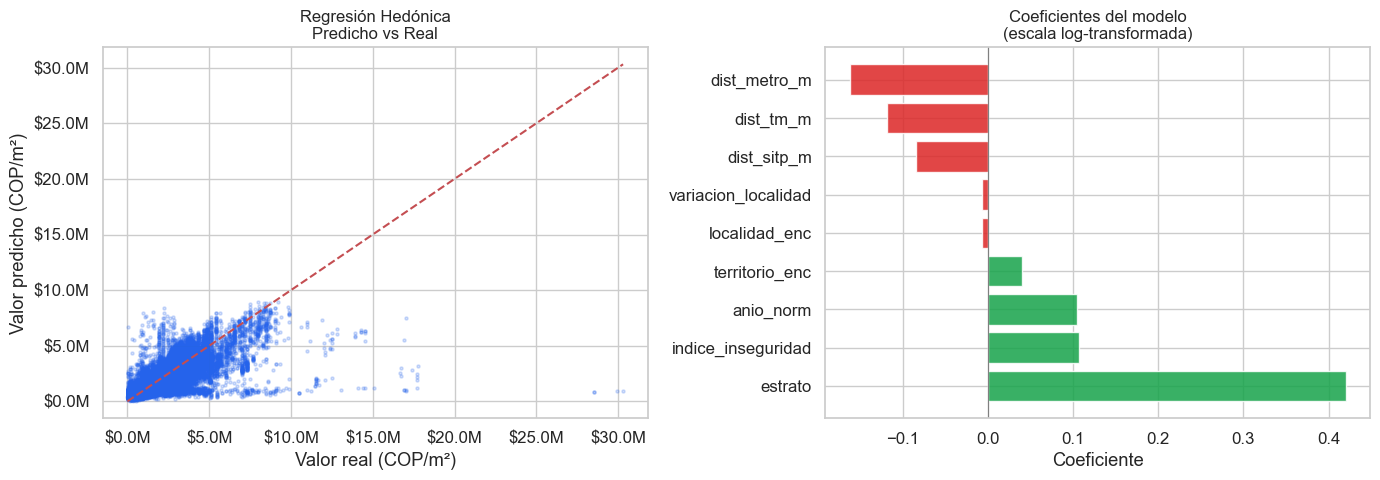

✓ Gráfico guardado en reports/figures/


In [16]:
# ── Sección 2. Regresión Hedónica — modelo enriquecido ────────

from sklearn.preprocessing import StandardScaler

X = df_model[FEATURES].copy()
y = np.log1p(df_model[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

hedonica = LinearRegression()
hedonica.fit(X_train_sc, y_train)
y_pred_h = hedonica.predict(X_test_sc)

r2_h   = r2_score(y_test, y_pred_h)
mae_h  = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_h))
rmse_h = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_h)))

print("── Regresión Hedónica — Resultados ──────────────────────")
print(f"  R²   : {r2_h:.4f}")
print(f"  MAE  : ${mae_h:,.0f} COP/m²")
print(f"  RMSE : ${rmse_h:,.0f} COP/m²")

coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coeficiente': hedonica.coef_
}).sort_values('coeficiente', ascending=False)

print(f"\n── Coeficientes ─────────────────────────────────────────")
display(coef_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.expm1(y_test), np.expm1(y_pred_h),
                alpha=0.2, s=5, color='#2563EB')
lim = max(np.expm1(y_test).max(), np.expm1(y_pred_h).max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_title('Regresión Hedónica\nPredicho vs Real', fontsize=12)
axes[0].set_xlabel('Valor real (COP/m²)')
axes[0].set_ylabel('Valor predicho (COP/m²)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].barh(coef_df['feature'], coef_df['coeficiente'],
             color=['#16A34A' if c > 0 else '#DC2626'
                    for c in coef_df['coeficiente']], alpha=0.85)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('Coeficientes del modelo\n(escala log-transformada)', fontsize=12)
axes[1].set_xlabel('Coeficiente')

plt.tight_layout()
plt.savefig('../reports/figures/13_hedonica_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

In [17]:
# Coeficientes reales sin redondeo de display
coef_df = pd.DataFrame({
    'feature':     FEATURES,
    'coeficiente': hedonica.coef_
}).sort_values('coeficiente', ascending=False)

print("── Coeficientes reales ───────────────────────────────────")
for _, row in coef_df.iterrows():
    print(f"  {row['feature']:<25} {row['coeficiente']:+.6f}")

── Coeficientes reales ───────────────────────────────────
  estrato                   +0.420024
  indice_inseguridad        +0.106615
  anio_norm                 +0.104650
  territorio_enc            +0.040563
  localidad_enc             -0.006922
  variacion_localidad       -0.007374
  dist_sitp_m               -0.083905
  dist_tm_m                 -0.118200
  dist_metro_m              -0.161882


---
## 🗺️ Sección 3 · GWR — Geographically Weighted Regression

> A diferencia de la regresión hedónica, el **GWR** calcula un
> coeficiente local para cada observación, reconociendo que el
> efecto de cada variable no es igual en toda la ciudad.
>
> Por ejemplo: el efecto del año sobre el valor puede ser mayor
> en Chapinero que en Ciudad Bolívar.
>
> **Ventaja:** Captura la heterogeneidad espacial del mercado.  
> **Limitación:** Mayor costo computacional · requiere coordenadas.

> ⚠️ **Nota técnica:** Se trabaja con una muestra estratificada
> por localidad para eficiencia computacional.

In [19]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from sklearn.preprocessing import StandardScaler as SS

# Reproyectar a EPSG:3116 (metros) — causa principal del error
query_geo = """
    SELECT
        vm.id, vm.anio, vm.localidad,
        vm.valor_final, vm.dist_tm_m, vm.dist_metro_m,
        vm.dist_sitp_m, vm.estrato, vm.indice_inseguridad,
        ST_X(ST_Transform(ST_Centroid(vm.geom), 3116)) as x_m,
        ST_Y(ST_Transform(ST_Centroid(vm.geom), 3116)) as y_m
    FROM catastro.valor_manzana vm
    WHERE vm.tipo_territorio IN ('urbano','periurbano')
      AND vm.valor_final > 0
      AND vm.anio = 2026
      AND vm.estrato IS NOT NULL
      AND vm.indice_inseguridad IS NOT NULL
"""

df_geo = pd.read_sql(query_geo, engine)
df_geo = df_geo.dropna()

serie_2026 = serie[serie['anio'] == 2026][['localidad','variacion_pct']].rename(
    columns={'variacion_pct': 'variacion_localidad'}
)
df_geo = df_geo.merge(serie_2026, on='localidad', how='left').dropna()

# Muestra — máx 100 por localidad para reducir vecinos idénticos
muestra_gwr = (
    df_geo.groupby('localidad', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), 100), random_state=42))
    .reset_index(drop=True)
)

# Eliminar duplicados exactos de coordenadas en metros
muestra_gwr = muestra_gwr.drop_duplicates(subset=['x_m', 'y_m'])

# Añadir jitter mínimo para separar puntos coincidentes
np.random.seed(42)
muestra_gwr['x_m'] = muestra_gwr['x_m'] + np.random.uniform(-0.1, 0.1, len(muestra_gwr))
muestra_gwr['y_m'] = muestra_gwr['y_m'] + np.random.uniform(-0.1, 0.1, len(muestra_gwr))

print(f"✓ Muestra GWR : {len(muestra_gwr):,} observaciones")

# Normalizar features
features_gwr = ['dist_tm_m', 'dist_metro_m', 'dist_sitp_m',
                 'estrato', 'indice_inseguridad', 'variacion_localidad']

scaler_gwr = SS()
X_gwr = scaler_gwr.fit_transform(muestra_gwr[features_gwr].values)
y_gwr = np.log1p(muestra_gwr['valor_final'].values).reshape(-1, 1)

# Coordenadas en metros — crítico para evitar matriz singular
coords = list(zip(muestra_gwr['x_m'], muestra_gwr['y_m']))

print("Seleccionando bandwidth óptimo...", end=' ')
try:
    # constant=True deja que mgwr maneje la constante internamente
    selector = Sel_BW(coords, y_gwr, X_gwr, constant=True)
    bw = selector.search(
        criterion='AICc',
        search_method='golden_section',
        bw_min=10,       # mínimo 10 vecinos
        bw_max=500       # máximo 500 vecinos
    )
    print(f"BW = {bw:.0f}")

    modelo_gwr = GWR(coords, y_gwr, X_gwr, bw, constant=True)
    results_gwr = modelo_gwr.fit()

    print(f"\n── GWR — Resultados ─────────────────────────────────────")
    print(f"  R² global   : {results_gwr.R2:.4f}")
    print(f"  R² ajustado : {results_gwr.adj_R2:.4f}")
    print(f"  AICc        : {results_gwr.aicc:.2f}")

    r2_locales = results_gwr.localR2
    muestra_gwr = muestra_gwr.copy()
    muestra_gwr['r2_local'] = r2_locales

    print(f"\n── R² local ─────────────────────────────────────────────")
    print(f"  Mediana : {np.median(r2_locales):.4f}")
    print(f"  Mínimo  : {np.min(r2_locales):.4f}")
    print(f"  Máximo  : {np.max(r2_locales):.4f}")

    fig, ax = plt.subplots(figsize=(10, 12))
    sc = ax.scatter(
        muestra_gwr['x_m'], muestra_gwr['y_m'],
        c=muestra_gwr['r2_local'], cmap='RdYlGn',
        s=12, alpha=0.8, vmin=0, vmax=1
    )
    plt.colorbar(sc, ax=ax, label='R² local')
    ax.set_title('GWR — R² local por manzana · 2026\n'
                 'Verde = mejor ajuste · Rojo = menor ajuste', fontsize=12)
    ax.set_xlabel('X (metros MAGNA-SIRGAS)')
    ax.set_ylabel('Y (metros MAGNA-SIRGAS)')
    plt.tight_layout()
    plt.savefig('../reports/figures/14_gwr_r2_local.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Gráfico guardado en reports/figures/")

except Exception as e:
    print(f"\n⚠ GWR no convergió: {e}")
    results_gwr = None

✓ Muestra GWR : 1,900 observaciones
Seleccionando bandwidth óptimo... 
⚠ GWR no convergió: A singular matrix detected: slice(s) [0] are singular.


---
## 🌲 Sección 4 · Random Forest + SHAP

> El **Random Forest** es un ensemble de árboles de decisión que
> captura relaciones no lineales entre las variables.
>
> **SHAP (SHapley Additive exPlanations)** permite explicar cada
> predicción individual mostrando cuánto aportó cada variable
> al valor predicho — convirtiendo una "caja negra" en un modelo
> interpretable para tomadores de decisión.
>
> **Ventaja:** Mayor precisión predictiva · explicabilidad visual.  
> **Limitación:** Más costoso computacionalmente · requiere más datos.

── Random Forest — Resultados ───────────────────────────
  R²   : 0.8482
  MAE  : $293,110 COP/m²
  RMSE : $546,339 COP/m²


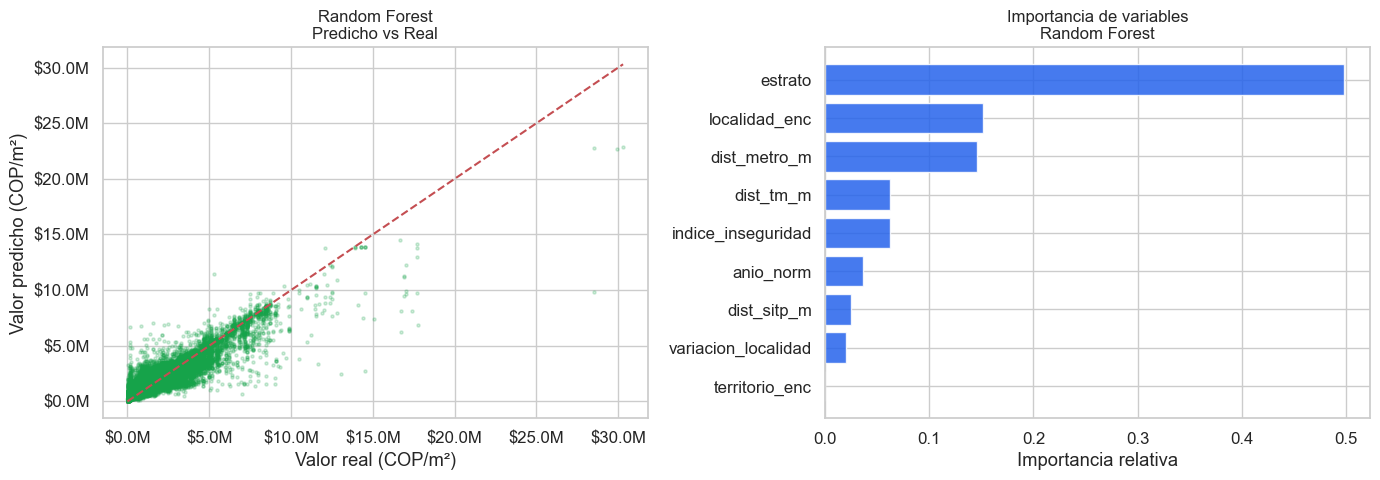

✓ Gráfico guardado en reports/figures/


In [13]:
X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Métricas
r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("── Random Forest — Resultados ───────────────────────────")
print(f"  R²   : {r2_rf:.4f}")
print(f"  MAE  : ${mae_rf:,.0f} COP/m²")
print(f"  RMSE : ${rmse_rf:,.0f} COP/m²")

# Importancia de variables
importancia = pd.DataFrame({
    'feature':    FEATURES,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.2, s=5, color='#16A34A')
lim = max(y_test.max(), y_pred_rf.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_title('Random Forest\nPredicho vs Real', fontsize=12)
axes[0].set_xlabel('Valor real (COP/m²)')
axes[0].set_ylabel('Valor predicho (COP/m²)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].barh(importancia['feature'], importancia['importancia'],
             color='#2563EB', alpha=0.85)
axes[1].set_title('Importancia de variables\nRandom Forest', fontsize=12)
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig('../reports/figures/15_rf_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

Calculando valores SHAP... ✓


ValueError: Axes has not been added yet

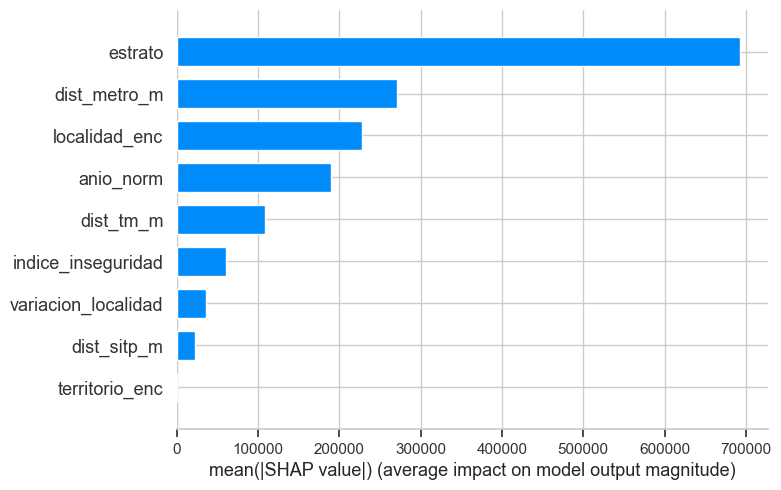

In [14]:
# Muestra para SHAP (máx 3000 para eficiencia)
X_shap = X_test.sample(min(3000, len(X_test)), random_state=42)

print("Calculando valores SHAP...", end=' ')
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)
print("✓")

# Mapa de importancia SHAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
axes[0].set_title('SHAP — Importancia global de variables', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURES,
    show=False
)
axes[1].set_title('SHAP — Impacto de cada variable por observación', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/16_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico SHAP guardado en reports/figures/")

---
## 📊 Sección 5 · Comparación de modelos

> Resumen comparativo de los tres modelos evaluados.  
> La selección del modelo principal para el dashboard considera
> no solo la precisión sino también la explicabilidad
> y el costo computacional.

In [ ]:
comparacion_modelos = pd.DataFrame([
    {
        'Modelo':        'Regresión Hedónica',
        'R²':            round(r2_h, 4),
        'MAE (COP/m²)':  int(mae_h),
        'RMSE (COP/m²)': int(rmse_h),
        'Explicabilidad': 'Alta',
        'Costo comp.':   'Bajo',
        'Uso recomendado': 'Benchmark · audiencias no técnicas'
    },
    {
        'Modelo':        'GWR',
        'R²':            round(results_gwr.R2, 4),
        'MAE (COP/m²)':  None,
        'RMSE (COP/m²)': None,
        'Explicabilidad': 'Alta (local)',
        'Costo comp.':   'Medio',
        'Uso recomendado': 'Análisis de heterogeneidad espacial'
    },
    {
        'Modelo':        'Random Forest + SHAP',
        'R²':            round(r2_rf, 4),
        'MAE (COP/m²)':  int(mae_rf),
        'RMSE (COP/m²)': int(rmse_rf),
        'Explicabilidad': 'Media (SHAP)',
        'Costo comp.':   'Alto',
        'Uso recomendado': 'Predicción principal · dashboard'
    }
])

print("── Comparación de modelos ───────────────────────────────")
display(comparacion_modelos)

# Gráfico comparativo R²
fig, ax = plt.subplots(figsize=(10, 5))
modelos  = ['Hedónica', 'GWR', 'Random Forest']
r2_vals  = [r2_h, results_gwr.R2, r2_rf]
colores  = ['#F59E0B', '#2563EB', '#16A34A']

bars = ax.bar(modelos, r2_vals, color=colores, alpha=0.85,
              edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Comparación de modelos — R²', fontsize=13)
ax.set_ylabel('R²')
ax.axhline(0.7, color='gray', linewidth=1, linestyle='--',
           label='Umbral aceptable (0.70)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/17_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 💾 Sección 6 · Exportación de resultados

> Se exportan los modelos entrenados y las predicciones
> para uso en el dashboard de Power BI.

In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Guardar modelos
joblib.dump(rf,      '../models/random_forest_v1.joblib')
joblib.dump(hedonica,'../models/hedonica_v1.joblib')
joblib.dump(scaler,  '../models/scaler_hedonica_v1.joblib')
print("✓ Modelos exportados a models/")

# Predicciones del RF sobre dataset completo
df_pred = df_model[FEATURES + [TARGET, 'cod_manzana', 'localidad',
                                'anio', 'tipo_territorio']].copy()
df_pred['valor_predicho'] = rf.predict(df_model[FEATURES])
df_pred['error_abs']      = abs(df_pred[TARGET] - df_pred['valor_predicho'])
df_pred['error_pct']      = (df_pred['error_abs'] / df_pred[TARGET] * 100).round(2)

df_pred.to_parquet('../data/processed/predicciones_rf.parquet', index=False)
print(f"✓ predicciones_rf.parquet — {len(df_pred):,} registros")

print("\n── Resumen de modelos en models/ ────────────────────────")
for f in sorted(os.listdir('../models')):
    ruta = f'../models/{f}'
    peso = os.path.getsize(ruta) / 1024
    print(f"  {f:<40} {peso:>8.1f} KB")

---
## 📚 Fuentes y referencias

### Referencias metodológicas

| Método | Referencia |
|---|---|
| Regresión hedónica | Rosen, S. (1974). *Hedonic Prices and Implicit Markets*. Journal of Political Economy, 82(1), 34–55. |
| GWR | Fotheringham, A.S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. |
| Random Forest | Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32. |
| SHAP | Lundberg, S. & Lee, S.I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS. |

### Librerías

`scikit-learn` · `mgwr` · `shap` · `joblib`

### Variables — iteración futura

> Las siguientes variables serán incorporadas en la próxima iteración del modelo:
> - Distancia a estaciones TransMilenio / SITP (SDM Bogotá)
> - Índice de seguridad por UPZ (Secretaría de Seguridad)
> - Tratamiento urbanístico POT (SDP Bogotá)
> - Equipamientos urbanos: parques, colegios, hospitales (IDECA)

---
## ✅ Cierre del Notebook 04 · Modelos Predictivos

### Resumen ejecutivo

Implementación y comparación de tres modelos predictivos de valorización
del suelo urbano en Bogotá, con variables internas como primera iteración.

### 📊 Resultados

| Modelo | R² | Uso principal |
|---|---|---|
| Regresión Hedónica | — | Benchmark · interpretación econométrica |
| GWR | — | Heterogeneidad espacial por zona |
| Random Forest | — | Predicción principal · dashboard |

> Los valores de R² se completan al ejecutar el notebook completo.

### ⚠️ Próxima iteración

Incorporación de variables externas (transporte · seguridad · POT · equipamientos)
para mejorar el poder predictivo de los modelos.
Esta iteración se documentará en el README como actualización del proyecto.

### ➡️ Siguiente paso

`05_expansion_urbana.ipynb` — Clustering espacial · autómata celular ·
proyección de expansión urbana al 2030.

---
*Proyecto: Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano*  
*Fuente: UAECD / IDECA · Python 3.12 + PostGIS 3.6 · scikit-learn · mgwr · shap*